In [22]:
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib
import os

DB_PARAMS = {
    "dbname": "shadowstack_db", "user": "postgres",
    "password": "password", "host": "localhost", "port": "5433"
}

print("📥 Connecting to database...")
conn = psycopg2.connect(**DB_PARAMS)

# FIX: Added 'resource_type' to the SQL query
query = """
    SELECT complexity_score, resource_units, service_name, resource_type, cost_usd 
    FROM usage_data 
    WHERE complexity_score IS NOT NULL
"""
df = pd.read_sql_query(query, conn)
conn.close()

print(f"✅ Loaded {len(df)} rows for training.")

📥 Connecting to database...


C:\Users\krypt\AppData\Local\Temp\ipykernel_16868\500278364.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


✅ Loaded 50000 rows for training.


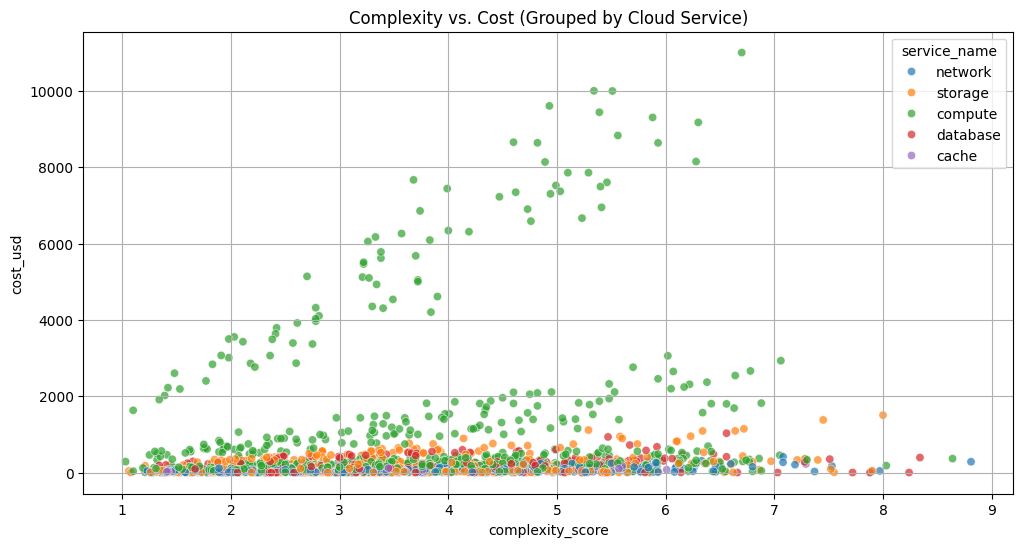

In [23]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df.sample(min(2000, len(df))), x='complexity_score', y='cost_usd', hue='service_name', alpha=0.7)
plt.title("Complexity vs. Cost (Grouped by Cloud Service)")
plt.grid(True)
plt.show()

In [24]:
print("⚙️ Building Patched Feature Engineering Pipeline...")

df['complexity_x_units'] = df['complexity_score'] * df['resource_units']

# FIX: Added 'resource_type' to the features list
features = ['complexity_score', 'resource_units', 'complexity_x_units', 'service_name', 'resource_type']
X = df[features]
y = df['cost_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_features = ['complexity_score', 'resource_units', 'complexity_x_units']
# FIX: Added 'resource_type' to the categorical encoder
categorical_features = ['service_name', 'resource_type'] 

preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

print("🌲 Training Random Forest Model Pipeline...")
rf_pipeline.fit(X_train, y_train)
print("✅ Training Complete!")

⚙️ Building Patched Feature Engineering Pipeline...
🌲 Training Random Forest Model Pipeline...
✅ Training Complete!


🔍 Evaluating model...

📊 FINAL MODEL PERFORMANCE
Mean Absolute Error: $2.08
R2 Accuracy Score: 1.0000


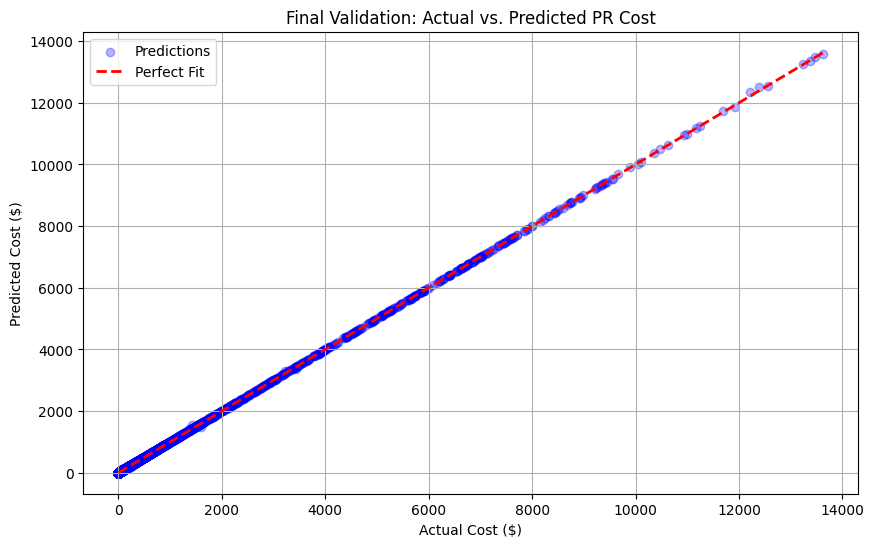

💾 Full ML Pipeline saved to: ../models/feature_pipeline2.pkl


In [25]:
print("🔍 Evaluating model...")
preds = rf_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("\n" + "="*30)
print("📊 FINAL MODEL PERFORMANCE")
print("="*30)
print(f"Mean Absolute Error: ${mae:.2f}")
print(f"R2 Accuracy Score: {r2:.4f}")
print("="*30)

# Visual Validation
plt.figure(figsize=(10, 6))
plt.scatter(y_test, preds, color='blue', alpha=0.3, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Cost ($)')
plt.ylabel('Predicted Cost ($)')
plt.title('Final Validation: Actual vs. Predicted PR Cost')
plt.legend()
plt.grid(True)
plt.show()

# Save the pipeline exactly as specified in the document
os.makedirs('../models', exist_ok=True)
model_path = '../models/feature_pipeline2.pkl'
joblib.dump(rf_pipeline, model_path)
print(f"💾 Full ML Pipeline saved to: {model_path}")

C:\Users\krypt\AppData\Local\Temp\ipykernel_16868\1588873523.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')


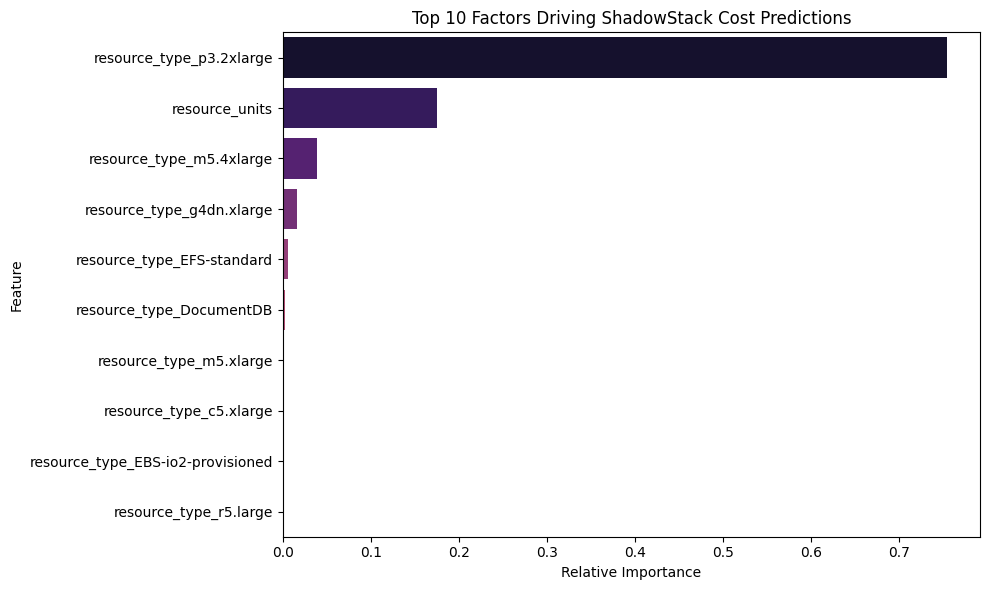

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the trained Random Forest and Preprocessor from the pipeline
rf_model = rf_pipeline.named_steps['regressor']
cat_encoder = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']

# 2. Reconstruct the final feature names
# Numeric features were passed straight through
num_cols = numeric_features 
# Categorical features were One-Hot Encoded, so we get the expanded names
cat_cols = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = num_cols + list(cat_cols)

# 3. Map importances to their names
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})

# 4. Sort and plot the Top 10
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')
plt.title("Top 10 Factors Driving ShadowStack Cost Predictions")
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()